In [1]:
import os
import zipfile
import pickle as pkl
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Define paths based on GSAT instructions
DATA_DIR = './data/mutag/raw'
ZIP_FILE = os.path.join(DATA_DIR, 'Mutagenicity.zip')
PKL_ZIP_FILE = os.path.join(DATA_DIR, 'Mutagenicity.pkl.zip')
PKL_FILE = os.path.join(DATA_DIR, 'Mutagenicity.pkl')

# Helper: Unzip the files if they haven't been unzipped yet
def extract_files():
    for z_file in [ZIP_FILE, PKL_ZIP_FILE]:
        if os.path.exists(z_file):
            print(f"Extracting {z_file}...")
            with zipfile.ZipFile(z_file, 'r') as zip_ref:
                zip_ref.extractall(DATA_DIR)
        else:
            print(f"Warning: {z_file} not found. Make sure you downloaded it.")

extract_files()

Extracting ./data/mutag/raw/Mutagenicity.zip...
Extracting ./data/mutag/raw/Mutagenicity.pkl.zip...


In [2]:
# Load the Pickle file
print(f"Loading {PKL_FILE}...")
with open(PKL_FILE, 'rb') as fin:
    adjs, features, labels = pkl.load(fin)

print("\n--- Pickle File Contents ---")
print(f"Type of adjs: {type(adjs)}")
print(f"Type of features: {type(features)}")
print(f"Type of labels: {type(labels)}")

# If they are numpy arrays (which is typical for PGExplainer's dense format)
if isinstance(adjs, np.ndarray):
    print(f"\nNumber of Graphs: {adjs.shape[0]}")
    print(f"Adjacency Matrix Shape (per graph): {adjs.shape[1:]} (Max Nodes)")
    print(f"Node Features Shape (per graph): {features.shape[1:]} (Max Nodes x Feature Dim)")
    print(f"Labels Shape: {labels.shape}")
else:
    # If they are lists
    print(f"\nNumber of Graphs: {len(adjs)}")
    print(f"Shape of first Adjacency Matrix: {adjs[0].shape}")
    print(f"Shape of first Node Feature Matrix: {features[0].shape}")

# Inspect Class distribution
unique, counts = np.unique(labels, return_counts=True)
print(f"\nClass Distribution: {dict(zip(unique, counts))}")
# Note: Usually, 1 = Mutagenic (contains NO2/NH2), 0 = Non-mutagenic

Loading ./data/mutag/raw/Mutagenicity.pkl...

--- Pickle File Contents ---
Type of adjs: <class 'numpy.ndarray'>
Type of features: <class 'numpy.ndarray'>
Type of labels: <class 'numpy.ndarray'>

Number of Graphs: 4337
Adjacency Matrix Shape (per graph): (418, 418) (Max Nodes)
Node Features Shape (per graph): (418, 14) (Max Nodes x Feature Dim)
Labels Shape: (4337, 2)

Class Distribution: {0.0: 4337, 1.0: 4337}


In [3]:
# List the raw files extracted from Mutagenicity.zip
raw_txt_dir = os.path.join(DATA_DIR, 'Mutagenicity') 
if not os.path.exists(raw_txt_dir):
    # Sometimes it extracts flat into the raw directory
    raw_txt_dir = DATA_DIR

print("\n--- Raw Text Files Available ---")
txt_files = [f for f in os.listdir(raw_txt_dir) if f.endswith('.txt')]
for f in txt_files:
    print(f)

# Let's specifically look for the edge ground truth file
gt_file = [f for f in txt_files if 'edge_gt' in f.lower() or 'edge_labels' in f.lower()]

if gt_file:
    gt_path = os.path.join(raw_txt_dir, gt_file[0])
    print(f"\nFound Ground Truth File: {gt_file[0]}")
    
    # Load first 10 edge ground truth labels
    with open(gt_path, 'r') as f:
        gt_lines = [next(f).strip() for _ in range(10)]
    
    print("First 10 edge masks (1 means it is part of the NO2/NH2 motif, 0 means background):")
    print(gt_lines)
else:
    print("\nCould not find an explicit edge ground truth file in the raw text files.")


--- Raw Text Files Available ---
Mutagenicity_node_labels.txt
Mutagenicity_graph_labels.txt
Mutagenicity_A.txt
Mutagenicity_edge_gt.txt
Mutagenicity_edge_labels.txt
Mutagenicity_label_readme.txt
Mutagenicity_graph_indicator.txt

Found Ground Truth File: Mutagenicity_edge_gt.txt
First 10 edge masks (1 means it is part of the NO2/NH2 motif, 0 means background):
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0']


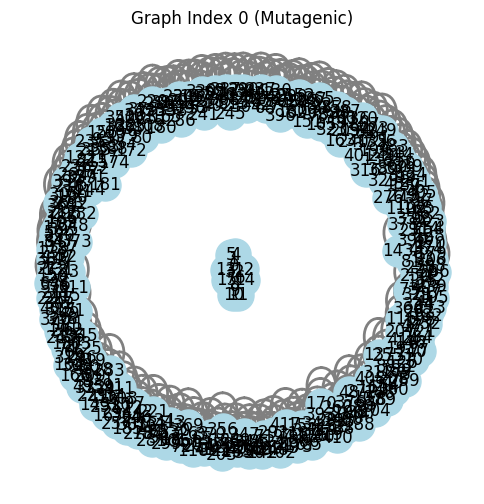

In [4]:
# Choose a graph index that is classified as Mutagenic (Label == 1)
# Mutagenic graphs are the ones that actually contain the motifs
mutagenic_indices = np.where(labels == 1)[0]
graph_idx = mutagenic_indices[0] # Pick the first mutagenic graph

# Extract the dense adjacency matrix for this specific graph
adj_matrix = adjs[graph_idx]

# If the adjacency matrix is padded (e.g., fixed max nodes), we need to filter out dummy nodes
# Usually, dummy nodes have 0 connections or a specific feature vector of all 0s
if isinstance(adj_matrix, np.ndarray):
    # Summing rows to find active nodes (degree > 0)
    active_nodes = np.where(adj_matrix.sum(axis=1) > 0)[0]
    sub_adj = adj_matrix[np.ix_(active_nodes, active_nodes)]
else:
    sub_adj = adj_matrix # Assuming it's already an exact sparse matrix

# Create NetworkX graph
G = nx.from_numpy_array(sub_adj)

# Visualization
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G, seed=42)

# By default, draw all edges in gray
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=2)
nx.draw_networkx_labels(G, pos)

plt.title(f"Graph Index {graph_idx} (Mutagenic)")
plt.axis('off')
plt.show()

Graph ID: 1 | Label: 0


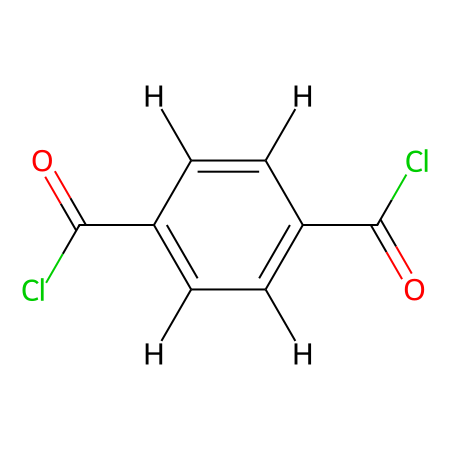

In [11]:
from rdkit import Chem
from rdkit.Chem import Draw, rdDepictor
from IPython.display import display

raw_dir = DATA_DIR
A_path = os.path.join(raw_dir, "Mutagenicity_A.txt")
node_labels_path = os.path.join(raw_dir, "Mutagenicity_node_labels.txt")
edge_labels_path = os.path.join(raw_dir, "Mutagenicity_edge_labels.txt")
edge_gt_path = os.path.join(raw_dir, "Mutagenicity_edge_gt.txt")
graph_indicator_path = os.path.join(raw_dir, "Mutagenicity_graph_indicator.txt")
graph_labels_path = os.path.join(raw_dir, "Mutagenicity_graph_labels.txt")
label_readme_path = os.path.join(raw_dir, "Mutagenicity_label_readme.txt")

def _load_txt(path):
    return np.loadtxt(path, delimiter=",", dtype=int)

edges = _load_txt(A_path)
if edges.ndim == 1:
    edges = edges.reshape(1, 2)
node_labels = _load_txt(node_labels_path)
edge_labels = _load_txt(edge_labels_path)
edge_gt = _load_txt(edge_gt_path)
graph_indicator = _load_txt(graph_indicator_path)
graph_labels = _load_txt(graph_labels_path)

def _parse_atom_map(readme_path):
    if not os.path.exists(readme_path):
        return None
    atom_map_local = {}
    in_node_section = False
    for line in open(readme_path, "r"):
        text = line.strip()
        if text.startswith("Node labels were converted"):
            in_node_section = True
            continue
        if in_node_section and text.startswith("Edge labels"):
            break
        if in_node_section:
            parts = text.split()
            if len(parts) == 2 and parts[0].isdigit():
                atom_map_local[int(parts[0])] = parts[1]
    return atom_map_local if atom_map_local else None

atom_map = _parse_atom_map(label_readme_path) or {
    0: "C",
    1: "O",
    2: "Cl",
    3: "H",
    4: "N",
    5: "F",
    6: "Br",
    7: "S",
    8: "P",
    9: "I",
    10: "Na",
    11: "K",
    12: "Li",
    13: "Ca",
}

bond_map = {
    0: Chem.BondType.SINGLE,
    1: Chem.BondType.DOUBLE,
    2: Chem.BondType.TRIPLE,
}

def _sanitize_fallback(mol):
    try:
        Chem.SanitizeMol(mol)
        return
    except Exception:
        pass
    try:
        Chem.SanitizeMol(
            mol,
            sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL ^ Chem.SanitizeFlags.SANITIZE_PROPERTIES,
        )
        return
    except Exception:
        Chem.SanitizeMol(
            mol,
            sanitizeOps=
                Chem.SanitizeFlags.SANITIZE_ALL
                ^ Chem.SanitizeFlags.SANITIZE_PROPERTIES
                ^ Chem.SanitizeFlags.SANITIZE_KEKULIZE,
        )

def build_mol_with_motif(graph_id):
    node_ids = np.where(graph_indicator == graph_id)[0] + 1
    node_id_to_local = {nid: idx for idx, nid in enumerate(node_ids)}

    edge_graph_ids = graph_indicator[edges[:, 0] - 1]
    mask = edge_graph_ids == graph_id
    edges_g = edges[mask]
    edge_labels_g = edge_labels[mask]
    edge_gt_g = edge_gt[mask]

    motif_per_key = {}
    bond_label_per_key = {}
    for (i, j), el, gt in zip(edges_g, edge_labels_g, edge_gt_g):
        if i == j:
            continue
        key = (min(i, j), max(i, j))
        motif_per_key[key] = max(motif_per_key.get(key, 0), int(gt))
        if key not in bond_label_per_key:
            bond_label_per_key[key] = int(el)

    mol = Chem.RWMol()
    for nid in node_ids:
        label = int(node_labels[nid - 1])
        atom_symbol = atom_map.get(label, "C")
        mol.AddAtom(Chem.Atom(atom_symbol))

    motif_bond_idxs = []
    motif_atoms = set()
    for key in sorted(motif_per_key.keys()):
        i, j = key
        bond_label = bond_label_per_key.get(key, 0)
        bond_type = bond_map.get(bond_label, Chem.BondType.SINGLE)
        mol.AddBond(node_id_to_local[i], node_id_to_local[j], bond_type)
        bond_idx = mol.GetNumBonds() - 1
        if motif_per_key[key] == 1:
            motif_bond_idxs.append(bond_idx)
            motif_atoms.update([node_id_to_local[i], node_id_to_local[j]])

    mol = mol.GetMol()
    _sanitize_fallback(mol)
    rdDepictor.Compute2DCoords(mol)
    return mol, sorted(motif_atoms), motif_bond_idxs

mutagen_graph_ids = np.where(graph_labels == 0)[0] + 1
graph_id = int(mutagen_graph_ids[0])
mol, motif_atoms, motif_bonds = build_mol_with_motif(graph_id)

highlight_atom_colors = {idx: (1.0, 0.6, 0.2) for idx in motif_atoms}
highlight_bond_colors = {idx: (1.0, 0.2, 0.2) for idx in motif_bonds}

img = Draw.MolToImage(
    mol,
    size=(450, 450),
    highlightAtoms=motif_atoms,
    highlightBonds=motif_bonds,
    highlightAtomColors=highlight_atom_colors,
    highlightBondColors=highlight_bond_colors,
)
print(f"Graph ID: {graph_id} | Label: {graph_labels[graph_id - 1]}")
display(img)

In [ ]:
import numpy as np

def create_node_mask(edge_index, edge_mask, num_nodes):

    node_mask = np.zeros(num_nodes, dtype=int)
    
    motif_edge_indices = np.where(edge_mask == 1)[0]
    
    for idx in motif_edge_indices:
        src_node = edge_index[0, idx]
        dst_node = edge_index[1, idx]
        
        node_mask[src_node] = 1
        node_mask[dst_node] = 1
        
    return node_mask

[13:23:39] Explicit valence for atom # 8 N, 4, is greater than permitted


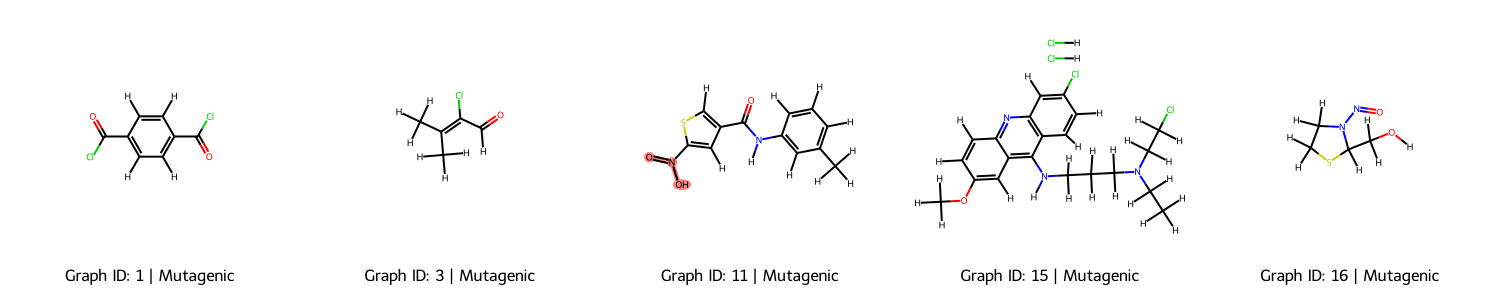

In [13]:
# Find the first 5 mutagenic graph IDs
# Note: Based on your previous output, label '0' corresponds to the mutagenic class here
mutagenic_graph_ids = np.where(graph_labels == 0)[0] + 1
selected_graph_ids = mutagenic_graph_ids[:5]

mols = []
highlight_atoms_list = []
highlight_bonds_list = []
legends = []

# Loop through the selected graph IDs and build the molecules
for gid in selected_graph_ids:
    graph_id = int(gid)
    mol, motif_atoms, motif_bonds = build_mol_with_motif(graph_id)
    
    mols.append(mol)
    # The motif_atoms list acts as our ground truth node mask
    highlight_atoms_list.append(motif_atoms)
    highlight_bonds_list.append(motif_bonds)
    legends.append(f"Graph ID: {graph_id} | Mutagenic")

# Draw the 5 molecules in a grid
img_grid = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,
    subImgSize=(300, 300),
    legends=legends,
    highlightAtomLists=highlight_atoms_list,
    highlightBondLists=highlight_bonds_list
)

# Display the grid
display(img_grid)

In [14]:
import numpy as np

def get_explainability_subset(graph_labels, graph_indicator, edges, edge_gt):
    """
    Filters the MUTAG dataset to find the specific subset of graphs 
    used for explainability evaluation in GSAT/PGExplainer.
    """
    eval_graph_ids = []
    
    # Get the total number of graphs
    num_graphs = len(graph_labels)
    
    for graph_idx in range(num_graphs):
        graph_id = graph_idx + 1 # graph_indicator is 1-indexed
        
        # 1. Check if the graph is mutagenic (Label == 0 in this specific split)
        if graph_labels[graph_idx] == 0:
            
            # 2. Find the edges that belong to this specific graph
            # We map the source node of each edge to its corresponding graph_id
            edge_mask = graph_indicator[edges[:, 0] - 1] == graph_id
            
            # 3. Extract the ground truth motif labels for these specific edges
            graph_edge_gt = edge_gt[edge_mask]
            
            # 4. If the graph has at least one motif edge (a '1' in the ground truth)
            if np.sum(graph_edge_gt) > 0:
                eval_graph_ids.append(graph_id)
                
    return eval_graph_ids

# Run the filter
eval_subset = get_explainability_subset(graph_labels, graph_indicator, edges, edge_gt)

print(f"Total graphs in raw dataset: {len(graph_labels)}")
print(f"Total mutagenic graphs: {np.sum(graph_labels == 0)}")
print(f"Mutagenic graphs WITH ground truth motifs (Eval Subset): {len(eval_subset)}")
print(f"First 10 graph IDs in the Evaluation Subset: {eval_subset[:10]}")

Total graphs in raw dataset: 4337
Total mutagenic graphs: 2401
Mutagenic graphs WITH ground truth motifs (Eval Subset): 1015
First 10 graph IDs in the Evaluation Subset: [11, 23, 26, 32, 34, 42, 43, 45, 46, 50]


[13:31:38] Explicit valence for atom # 8 N, 4, is greater than permitted
[13:31:38] Explicit valence for atom # 11 N, 4, is greater than permitted
[13:31:38] Explicit valence for atom # 10 N, 4, is greater than permitted


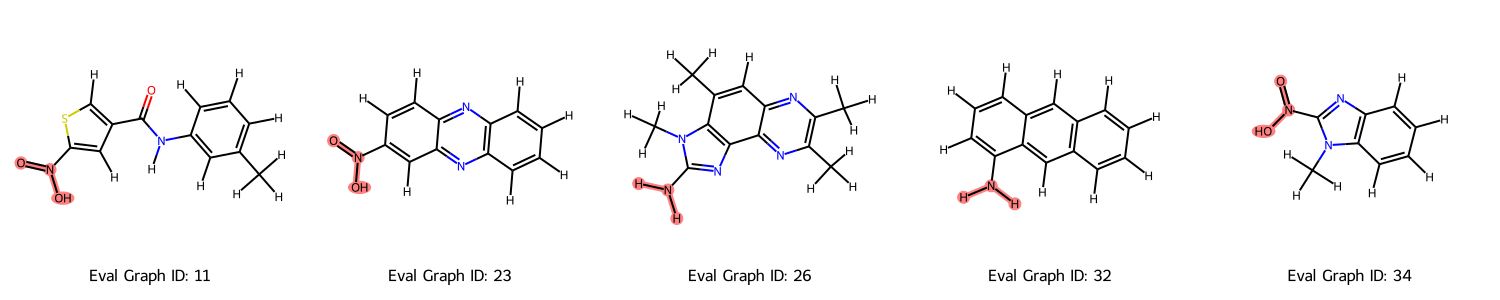

In [ ]:
selected_eval_ids = eval_subset[:5]

mols = []
highlight_atoms_list = []
highlight_bonds_list = []
legends = []

for graph_id in selected_eval_ids:
    mol, motif_atoms, motif_bonds = build_mol_with_motif(graph_id)
    
    mols.append(mol)
    
  
    highlight_atoms_list.append(motif_atoms)
    
    # We will include the edge mask too for visual clarity
    highlight_bonds_list.append(motif_bonds) 
    
    legends.append(f"Eval Graph ID: {graph_id}")

# Draw the 5 evaluation molecules in a grid
img_eval_grid = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,
    subImgSize=(300, 300),
    legends=legends,
    highlightAtomLists=highlight_atoms_list, # <--- Here is where the node mask is applied!
    highlightBondLists=highlight_bonds_list
)

# Display the final filtered grid
display(img_eval_grid)

MUTAG feature summary
---------------------
Graphs: 4337
Nodes: 131488
Edges: 266894

Node features (node labels)
Each node is a discrete atom-type label, not a continuous vector.
  0: C
  1: O
  2: Cl
  3: H
  4: N
  5: F
  6: Br
  7: S
  8: P
  9: I
  10: Na
  11: K
  12: Li
  13: Ca

Edge features (edge labels)
Each edge is a discrete bond-value label from the dataset.
  0: 1
  1: 2
  2: 3

What edge features tell us
- They encode bond order / valence information.
- 1, 2, 3 correspond to single, double, triple bond strengths in the dataset encoding.
- These are categorical chemistry descriptors, not learned features.

Node label counts:
  0 (C): 53856
  1 (O): 10645
  2 (Cl): 1312
  3 (H): 58205
  4 (N): 6006
  5 (F): 240
  6 (Br): 299
  7 (S): 654
  8 (P): 119
  9 (I): 23
  10 (Na): 112
  11 (K): 14
  12 (Li): 1
  13 (Ca): 2

Edge label counts:
  0 (1): 221000
  1 (2): 45674
  2 (3): 220


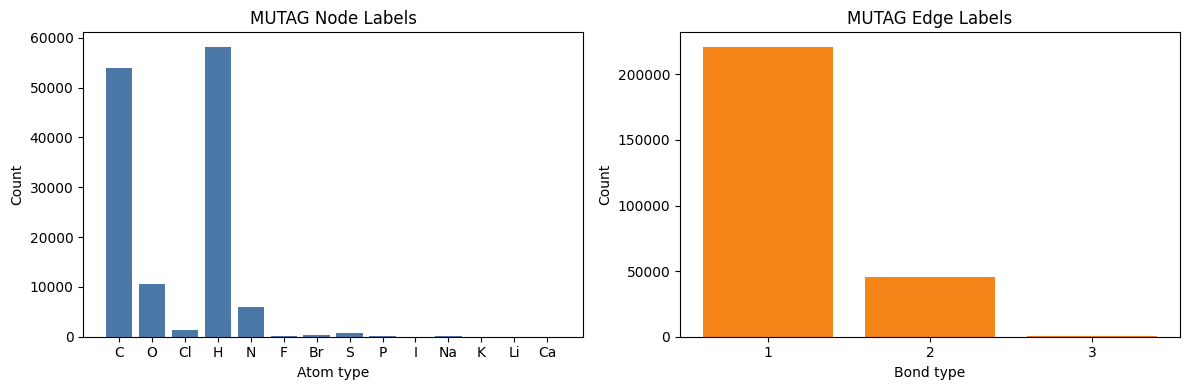

Sample graph 1:
  Nodes: 16
  Edges: 32
  First few edges with their bond labels:
    (1, 2) -> 1
    (2, 1) -> 1
    (1, 3) -> 1
    (3, 1) -> 1
    (1, 4) -> 2
    (4, 1) -> 2
    (2, 5) -> 2
    (5, 2) -> 2
    (2, 6) -> 1
    (6, 2) -> 1


In [17]:
# MUTAG node and edge feature exploration
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

mutag_raw_dir = Path(DATA_DIR)
if not mutag_raw_dir.exists():
    raise FileNotFoundError(f'Could not find MUTAG raw directory: {mutag_raw_dir}')

node_labels_path = mutag_raw_dir / 'Mutagenicity_node_labels.txt'
edge_labels_path = mutag_raw_dir / 'Mutagenicity_edge_labels.txt'
graph_labels_path = mutag_raw_dir / 'Mutagenicity_graph_labels.txt'
graph_indicator_path = mutag_raw_dir / 'Mutagenicity_graph_indicator.txt'
edge_path = mutag_raw_dir / 'Mutagenicity_A.txt'

node_labels_mutag = np.loadtxt(node_labels_path, dtype=int)
edge_labels_mutag = np.loadtxt(edge_labels_path, dtype=int)
graph_labels_mutag = np.loadtxt(graph_labels_path, dtype=int)
graph_indicator_mutag = np.loadtxt(graph_indicator_path, dtype=int)
edges_mutag = np.loadtxt(edge_path, dtype=int, delimiter=',')
if edges_mutag.ndim == 1:
    edges_mutag = edges_mutag.reshape(1, 2)

node_label_map = {
    0: 'C',
    1: 'O',
    2: 'Cl',
    3: 'H',
    4: 'N',
    5: 'F',
    6: 'Br',
    7: 'S',
    8: 'P',
    9: 'I',
    10: 'Na',
    11: 'K',
    12: 'Li',
    13: 'Ca',
}

edge_label_map = {
    0: '1',
    1: '2',
    2: '3',
}

print('MUTAG feature summary')
print('---------------------')
print(f'Graphs: {len(graph_labels_mutag)}')
print(f'Nodes: {len(node_labels_mutag)}')
print(f'Edges: {len(edge_labels_mutag)}')
print()
print('Node features (node labels)')
print('Each node is a discrete atom-type label, not a continuous vector.')
for k in sorted(node_label_map):
    print(f'  {k}: {node_label_map[k]}')
print()
print('Edge features (edge labels)')
print('Each edge is a discrete bond-value label from the dataset.')
for k in sorted(edge_label_map):
    print(f'  {k}: {edge_label_map[k]}')
print()
print('What edge features tell us')
print('- They encode bond order / valence information.')
print('- 1, 2, 3 correspond to single, double, triple bond strengths in the dataset encoding.')
print('- These are categorical chemistry descriptors, not learned features.')
print()
print('Node label counts:')
for label, count in sorted(Counter(node_labels_mutag).items()):
    node_name = node_label_map.get(int(label), '?')
    print(f'  {label} ({node_name}): {count}')
print()
print('Edge label counts:')
for label, count in sorted(Counter(edge_labels_mutag).items()):
    edge_name = edge_label_map.get(int(label), '?')
    print(f'  {label} ({edge_name}): {count}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

node_counts = Counter(node_labels_mutag)
axes[0].bar([node_label_map.get(k, str(k)) for k in node_counts.keys()], list(node_counts.values()), color='#4C78A8')
axes[0].set_title('MUTAG Node Labels')
axes[0].set_xlabel('Atom type')
axes[0].set_ylabel('Count')

edge_counts = Counter(edge_labels_mutag)
axes[1].bar([edge_label_map.get(k, str(k)) for k in edge_counts.keys()], list(edge_counts.values()), color='#F58518')
axes[1].set_title('MUTAG Edge Labels')
axes[1].set_xlabel('Bond type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

sample_graph_id = 1
sample_edge_mask = graph_indicator_mutag[edges_mutag[:, 0] - 1] == sample_graph_id
sample_edges = edges_mutag[sample_edge_mask]
sample_edge_labels = edge_labels_mutag[sample_edge_mask]

print(f'Sample graph {sample_graph_id}:')
print(f'  Nodes: {int((graph_indicator_mutag == sample_graph_id).sum())}')
print(f'  Edges: {len(sample_edges)}')
print('  First few edges with their bond labels:')
for (u, v), e_label in list(zip(sample_edges, sample_edge_labels))[:10]:
    print(f'    ({u}, {v}) -> {edge_label_map.get(int(e_label), e_label)}')

In [18]:
import torch
import numpy as np
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

# ==========================================
# 1. Balance the Dataset
# ==========================================
# Assuming 'graph_labels' array has 0 for Mutagenic and 1 for Non-Mutagenic
# eval_subset contains our ~1015 Mutagenic graphs WITH motifs
num_eval = len(eval_subset)

# Find all Non-Mutagenic graph IDs (1-indexed to match graph_indicator)
non_mutagenic_indices = np.where(graph_labels == 1)[0]
non_mutagenic_graph_ids = non_mutagenic_indices + 1

# Randomly sample Non-Mutagenic graphs to perfectly match the Mutagenic count
np.random.seed(42)
sampled_non_mutag_ids = np.random.choice(
    non_mutagenic_graph_ids, 
    size=num_eval, 
    replace=False
).tolist()

# Combine and create a master list of IDs and their corresponding labels
balanced_graph_ids = eval_subset + sampled_non_mutag_ids
balanced_labels = [0] * num_eval + [1] * num_eval

# ==========================================
# 2. Build PyTorch Geometric Dataset
# ==========================================
dataset = []

# MUTAG node labels range from 0 to 13 (14 total atom types)
NUM_NODE_FEATURES = 14 

def create_pyg_data(graph_id, label):
    # --- Nodes ---
    # Find the 0-indexed node positions for this graph
    node_indices = np.where(graph_indicator == graph_id)[0]
    
    # Extract node labels and convert to one-hot encoded features (N, 14)
    raw_n_labels = node_labels[node_indices]
    x = torch.zeros((len(node_indices), NUM_NODE_FEATURES), dtype=torch.float)
    x[torch.arange(len(node_indices)), raw_n_labels] = 1.0
    
    # --- Edges ---
    # Find edges belonging to this graph
    edge_mask_graph = graph_indicator[edges[:, 0] - 1] == graph_id
    edges_g = edges[edge_mask_graph]
    
    # The raw edges are globally 1-indexed. We must map them to local 0-indexed values for PyG
    node_id_to_local = {nid + 1: idx for idx, nid in enumerate(node_indices)}
    local_edges = np.array([[node_id_to_local[u], node_id_to_local[v]] for u, v in edges_g])
    
    # PyG expects edge_index of shape [2, num_edges]
    edge_index = torch.tensor(local_edges, dtype=torch.long).t().contiguous()

    raw_edge_labels = edge_labels[edge_mask_graph]

    NUM_EDGE_FEATURES = 3
    edge_attr = torch.zeros((edge_index.shape[1], NUM_EDGE_FEATURES), dtype=torch.float)
    edge_attr[torch.arange(edge_index.shape[1]), raw_edge_labels] = 1.0
    
    # --- Ground Truth Masks ---
    # Extract the edge motif mask
    edge_gt_g = edge_gt[edge_mask_graph]
    edge_attr_mask = torch.tensor(edge_gt_g, dtype=torch.float)
    
    # Derive the node motif mask from the edge mask
    node_attr_mask = torch.zeros(len(node_indices), dtype=torch.float)
    motif_edge_indices = np.where(edge_gt_g == 1)[0]
    
    for idx in motif_edge_indices:
        u, v = local_edges[idx]
        node_attr_mask[u] = 1.0
        node_attr_mask[v] = 1.0
        
    # --- Label ---
    y = torch.tensor([label], dtype=torch.long)
    
    # --- Construct Data Object ---
    data = Data(x=x, edge_index=edge_index,edge_attr=edge_attr, y=y)
    data.edge_mask = edge_attr_mask
    data.node_mask = node_attr_mask
    
    return data

# Populate the dataset list
for gid, lbl in zip(balanced_graph_ids, balanced_labels):
    dataset.append(create_pyg_data(gid, lbl))

# ==========================================
# 3. Train / Validation / Test Split
# ==========================================
# Using an 80/10/10 split. 
# stratify=balanced_labels ensures the 50/50 class balance is maintained across all splits.

train_data, temp_data, train_labels, temp_labels = train_test_split(
    dataset, balanced_labels, test_size=0.20, stratify=balanced_labels, random_state=42
)

val_data, test_data = train_test_split(
    temp_data, test_size=0.50, stratify=temp_labels, random_state=42
)

# ==========================================
# 4. Save to .pt file
# ==========================================
output_path = 'mutag_balanced_explainability.pt'
torch.save({
    'train': train_data,
    'val': val_data,
    'test': test_data
}, output_path)

print(f"Dataset successfully built and saved to '{output_path}'")
print(f"Train size: {len(train_data)} graphs")
print(f"Val size:   {len(val_data)} graphs")
print(f"Test size:  {len(test_data)} graphs")

/Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset successfully built and saved to 'mutag_balanced_explainability.pt'
Train size: 1624 graphs
Val size:   203 graphs
Test size:  203 graphs
